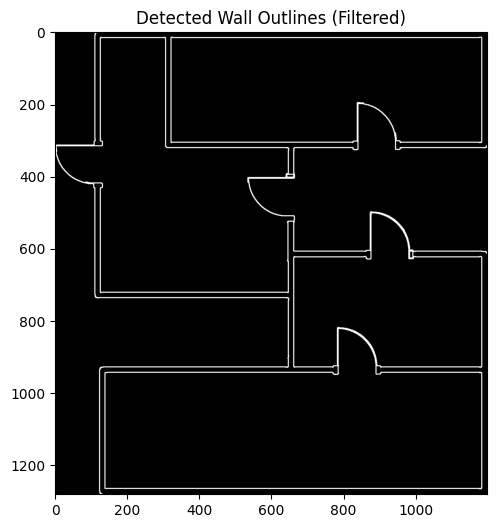

Wall coordinates saved to 'wall_coordinates.json'


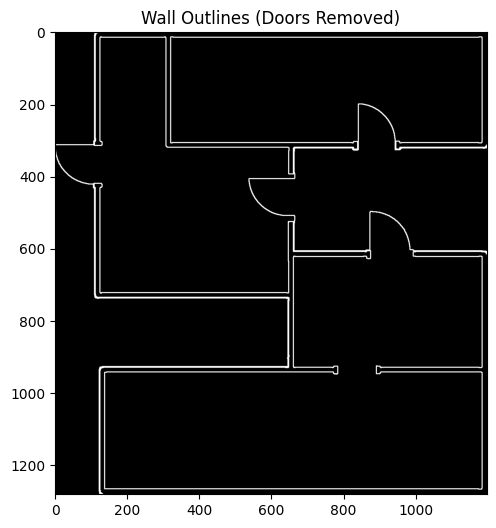

Wall coordinates saved to 'wall_coordinates_without_doors.json'


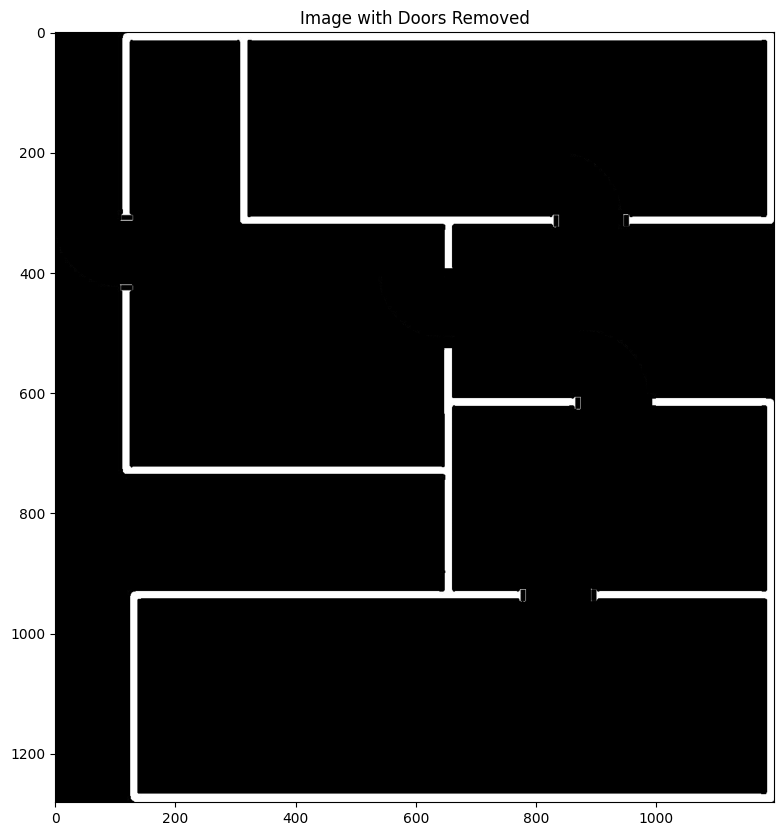

In [2]:
import cv2
import numpy as np
import json
from matplotlib import pyplot as plt

# Load the blueprint image
image_path = "images/test/Cat24_7.jpg"
image = cv2.imread(image_path, 0)  # Read the image in grayscale

# Invert the image so that walls are white on a black background
image_inverted = ~image

# Apply Canny Edge Detection to find edges
edges = cv2.Canny(image_inverted, threshold1=50, threshold2=150)

# Find contours from the edges detected
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a blank canvas to draw the contours (outlines of the walls)
output_image = np.zeros_like(image_inverted)

# Define a minimum contour area threshold (this will filter out smaller objects)
min_area = 292000  # Adjust this value depending on the image scale and resolution

# Loop over contours and filter by area
for contour in contours:
    area = cv2.contourArea(contour)
    if area > min_area:
        cv2.drawContours(output_image, [contour], -1, (255, 255, 255), 2)  # Draw only large contours

# Display the resulting image with the wall outlines
plt.figure(figsize=(6, 6))
plt.imshow(output_image, cmap='gray')
plt.title('Detected Wall Outlines (Filtered)')
plt.show()

# Find contours again on the filtered image
contours, _ = cv2.findContours(output_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Define thresholds for circularity and contour approximation to identify doors (semicircles)
max_aspect_ratio = 2.0  # Doors are generally more wide than high
max_circularity = 0.6   # Circularity threshold to catch arcs or semicircles

# Function to detect circular/semicircular shapes (e.g., doors)
def is_semi_circular(contour):
    # Approximate contour to reduce its complexity
    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.04 * perimeter, True)

    # Use bounding box to calculate aspect ratio (width/height)
    x, y, w, h = cv2.boundingRect(approx)
    aspect_ratio = float(w) / h
    
    # Calculate circularity (for semicircular contours)
    area = cv2.contourArea(contour)
    circularity = (4 * np.pi * area) / (perimeter * perimeter)

    # Check if it's a door (semicircular shape)
    if len(approx) > 5 and aspect_ratio < max_aspect_ratio and circularity < max_circularity:
        return True
    return False

# Create a blank image to draw only the walls without the doors
output_image_without_doors = np.zeros_like(image_inverted)

# Extract coordinates of wall contours
wall_coordinates = []

# Draw only walls (excluding semicircular shapes like doors)
for contour in contours:
    if not is_semi_circular(contour):
        cv2.drawContours(output_image_without_doors, [contour], -1, (255, 255, 255), 2)  # Draw only non-door contours
        
        # Convert contour points to a list of tuples (x, y) with standard Python int types
        contour_points = [(int(point[0][0]), int(point[0][1])) for point in contour]
        wall_coordinates.append(contour_points)

# Save coordinates of walls to a JSON file
with open('wall_coordinates.json', 'w') as file:
    json.dump(wall_coordinates, file, indent=4)

print("Wall coordinates saved to 'wall_coordinates.json'")

# Show the resulting image with doors removed
plt.figure(figsize=(6, 6))
plt.imshow(output_image_without_doors, cmap='gray')
plt.title('Wall Outlines (Doors Removed)')
plt.show()

# Now we proceed with another step to process the walls without the doors

# Load the coordinates of walls again
with open('wall_coordinates.json', 'r') as file:
    wall_coordinates = json.load(file)

# Create a mask to remove doors
mask = np.ones_like(image_inverted, dtype=np.uint8) * 255  # Start with a white mask

# Draw doors on the mask in black to "remove" them
for contour_points in wall_coordinates:
    contour_array = np.array(contour_points, dtype=np.int32)
    contour_array = contour_array.reshape((-1, 1, 2))  # Required shape for drawContours
    cv2.drawContours(mask, [contour_array], -1, (0, 0, 0), thickness=cv2.FILLED)  # Fill with black

# Apply the mask to the inverted image to remove doors
image_without_doors = cv2.bitwise_and(image_inverted, mask)

# Apply Canny Edge Detection to find edges in the image with doors removed
edges_without_doors = cv2.Canny(image_without_doors, 50, 150)

# Find contours from the edges detected
contours_without_doors, _ = cv2.findContours(edges_without_doors, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Define contour filtering criteria
max_area = 500000  # Maximum area to filter out large non-wall objects

# Extract coordinates of wall contours
wall_coordinates_without_doors = []
for contour in contours_without_doors:
    area = cv2.contourArea(contour)
    if min_area < area < max_area:
        # Calculate aspect ratio
        x, y, w, h = cv2.boundingRect(contour)
        aspect_ratio = float(w) / h
        
        if aspect_ratio < max_aspect_ratio:
            # Convert contour points to a list of tuples (x, y) with standard Python int types
            contour_points = [(int(point[0][0]), int(point[0][1])) for point in contour]
            wall_coordinates_without_doors.append(contour_points)

# Save coordinates of walls to a new JSON file
with open('wall_coordinates_without_doors.json', 'w') as file:
    json.dump(wall_coordinates_without_doors, file, indent=4)

print("Wall coordinates saved to 'wall_coordinates_without_doors.json'")

# Optional: Display the resulting image with doors removed
plt.figure(figsize=(10, 10))
plt.imshow(image_without_doors, cmap='gray')
plt.title('Image with Doors Removed')
plt.show()


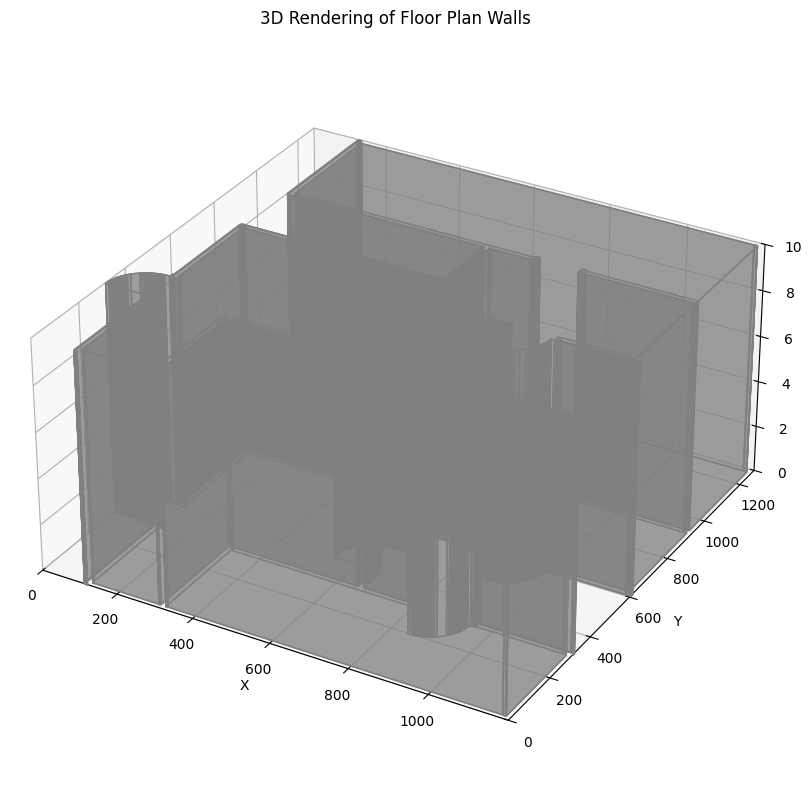

In [1]:
import json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Load wall coordinates from the JSON file
with open('wall_coordinates.json', 'r') as file:
    wall_coordinates = json.load(file)

# Parameters for wall height
wall_height = 10  # Uniform wall height, adjust as needed

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Function to create wall polygons in 3D
def create_wall_polygon(coords, height):
    # Create top and bottom polygons for the wall
    top_polygon = [[x, y, height] for x, y in coords]
    bottom_polygon = [[x, y, 0] for x, y in coords]
    wall_sides = []

    # Create side faces connecting the top and bottom polygons
    for i in range(len(coords)):
        next_index = (i + 1) % len(coords)
        wall_side = [
            [coords[i][0], coords[i][1], 0],  # Bottom current point
            [coords[next_index][0], coords[next_index][1], 0],  # Bottom next point
            [coords[next_index][0], coords[next_index][1], height],  # Top next point
            [coords[i][0], coords[i][1], height]  # Top current point
        ]
        wall_sides.append(wall_side)

    return top_polygon, bottom_polygon, wall_sides

# Get min and max values for setting axis limits
all_x = [x for wall in wall_coordinates for x, _ in wall]
all_y = [y for wall in wall_coordinates for _, y in wall]

# Plot each wall
for wall in wall_coordinates:
    top_polygon, bottom_polygon, wall_sides = create_wall_polygon(wall, wall_height)

    # Add top and bottom faces of the wall
    ax.add_collection3d(Poly3DCollection([top_polygon], color='gray', alpha=0.5))
    ax.add_collection3d(Poly3DCollection([bottom_polygon], color='gray', alpha=0.5))

    # Add the side faces of the wall
    for side in wall_sides:
        ax.add_collection3d(Poly3DCollection([side], color='gray', alpha=0.5))

# Set axis limits based on the range of coordinates
ax.set_xlim(min(all_x), max(all_x))
ax.set_ylim(min(all_y), max(all_y))
ax.set_zlim(0, wall_height)

# Set labels and axis limits
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Height')
ax.set_title('3D Rendering of Floor Plan Walls')

# Set equal scaling for all axes to maintain aspect ratio
ax.set_box_aspect([1, 1, 0.5])

# Display plot
plt.show()
